In [ ]:
!pip install kaggle

In [2]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount("/content/drive",force_remount=True)
#

Mounted at /content/drive


In [3]:
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv("/content/drive/MyDrive/Python/cicids2017_cleaned.csv")

df['Traffic_Type'] = df['Attack Type'].apply(
    lambda x: 'Normal' if x == 'Normal Traffic' else 'Attack'
)

print(f'Shape: {df.shape}')
print(f'\nAttack Type counts:')
print(df['Attack Type'].value_counts())

Shape: (2520751, 54)

Attack Type counts:
Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64


In [4]:

# =============================================================
# LINEAR REGRESSION
# Goal: Predict Flow Duration from network traffic features
# Note: Regression can't classify attacks directly — it predicts
# a continuous number. We use it to show attack traffic behaves
# differently even without a classifier.
# =============================================================

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Features and target
# Features selected based on EDA findings
# These 7 features showed the strongest separation between normal and attack traffic

features = ['Flow Packets/s',          # packet rate — high in scans, low in slow attacks
            'Flow Bytes/s',            # throughput — highest in normal traffic
            'Fwd Packet Length Mean',  # average forward packet size
            'Bwd Packet Length Mean',  # average backward packet size
            'ACK Flag Count',          # TCP acknowledgements — low in attack flows
            'Init_Win_bytes_forward',  # initial TCP window size — key attack indicator
            'Idle Mean']               # average idle time — correlated with flow duration

target = 'Flow Duration'  # what we are trying to predict (in microseconds)

# Remove zero-duration flows — these are single packet flows with no meaningful duration
# Keeping them would distort the regression since we can't predict duration of 0
data = df[df[target] > 0].copy().reset_index(drop=True)

X = data[features]  # feature matrix
y = data[target]    # target vector

print(f'Training data shape: {X.shape}')
print(f'\\nFeature summary:')
print(X.describe().round(2))

Training data shape: (2520644, 7)
\nFeature summary:
       Flow Packets/s  Flow Bytes/s  Fwd Packet Length Mean  \
count      2520644.00  2.520644e+06              2520644.00   
mean         47376.06  1.411261e+06                   63.50   
std         202225.25  2.657078e+07                  195.55   
min              0.02  0.000000e+00                    0.00   
25%              2.02  1.194400e+02                    6.00   
50%             69.77  3.715650e+03                   36.25   
75%          17857.14  1.071429e+05                   52.00   
max        4000000.00  2.071000e+09                 5940.86   

       Bwd Packet Length Mean  ACK Flag Count  Init_Win_bytes_forward  \
count              2520644.00      2520644.00              2520644.00   
mean                   340.63            0.31                 7265.63   
std                    632.54            0.46                14597.85   
min                      0.00            0.00                   -1.00   
25%           

In [5]:
from sklearn.preprocessing import StandardScaler

# Split data into training and test sets
# test_size=0.2 — 80% for training, 20% for testing
# random_state=42 — ensures reproducibility, same split every run
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# WHY SCALING?
# Our features live on very different scales:
#   Flow Bytes/s can be in the billions
#   ACK Flag Count is just 0 or 1
# Linear Regression treats a "1 unit change" the same across all features
# That's unfair — 1 unit in bytes means nothing, 1 unit in ACK count means everything
# StandardScaler fixes this by pulling every feature to the same scale (mean=0, std=1)
# Think of it as converting everything to a common unit before comparing

scaler = StandardScaler()

# Fit and scale the training data
# scaler learns the mean and std from training data here
X_train_scaled = scaler.fit_transform(X_train)

# Scale the test data using the SAME mean and std learned from training
# We never fit on test data — we haven't "seen" it yet in real life
# Fitting on test data would be cheating — the model would look better than it really is
X_test_scaled = scaler.transform(X_test)

print(f'Training set : {X_train_scaled.shape}')
print(f'Test set     : {X_test_scaled.shape}')

Training set : (2016515, 7)
Test set     : (504129, 7)


In [6]:
# Train
# Create and train the Linear Regression model
# lr.fit() is where the actual learning happens
# it finds the best straight line through the training data
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predict
# Use the trained model to predict Flow Duration on unseen test data
y_pred = lr.predict(X_test_scaled)


# Evaluate
# EVALUATE — how good are the predictions?

# R² Score — how much of the variation in Flow Duration does the model explain?
# R² = 1.0 would mean perfect predictions
# R² = 0.0 means the model is no better than just guessing the average every time
# Our result of 0.61 means the model explains 61% of the variation — moderate

# Mean Absolute Error (MAE) — on average, how many microseconds off is each prediction?
# We convert to seconds to make it human readable
# Our result of 11.37 seconds means the model is off by 11 seconds on average
# In network terms that's a large error — regression alone isn't enough for IDS

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'R² Score          : {r2:.4f}')
print(f'Mean Absolute Error: {mae:,.0f} microseconds')
print(f'                   : {mae/1e6:.2f} seconds')
# Coefficients — which features matter most
coef_df = pd.DataFrame({
'Feature': features,
'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(f'\nFeature Coefficients:')
print(coef_df.to_string(index=False))



R² Score          : 0.6113
Mean Absolute Error: 11,373,604 microseconds
                   : 11.37 seconds

Feature Coefficients:
               Feature   Coefficient
             Idle Mean  2.761857e+07
Init_Win_bytes_forward  4.761618e+06
        ACK Flag Count -2.195184e+06
Fwd Packet Length Mean  1.157505e+06
        Flow Packets/s -6.175151e+05
Bwd Packet Length Mean -4.558959e+05
          Flow Bytes/s -7.199318e+04


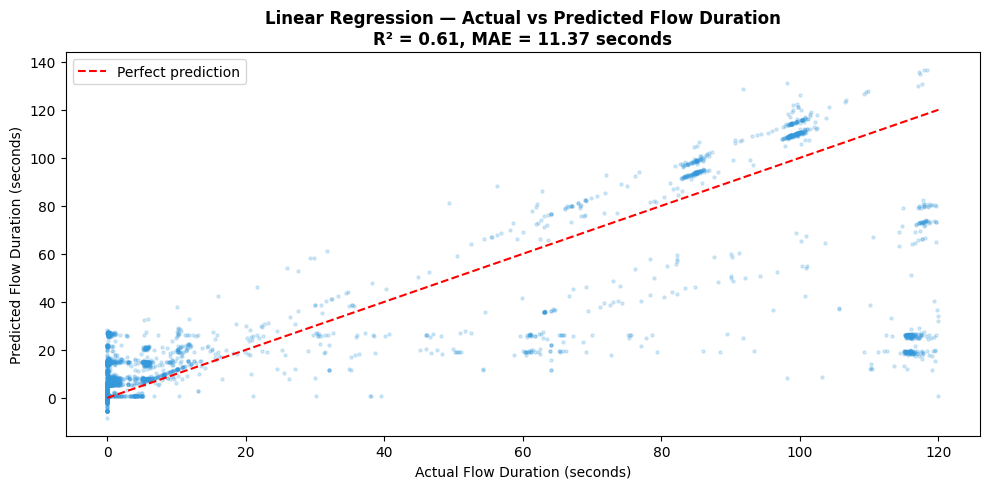

In [7]:
# Sample for plotting
# VISUALISE — Actual vs Predicted Flow Duration
# Each dot = one network flow from the test set
# X axis = how long the flow actually lasted
# Y axis = how long the model predicted it would last
# A perfect model would have every dot sitting exactly on the red dashed line
# Dots above the line = model overestimated duration
# Dots below the line = model underestimated duration
# The scatter around the line shows where the model struggles

# Plotting 5000 random samples instead of all 500K test rows
# Full dataset would take too long to render and the pattern is the same
sample_idx = np.random.choice(len(y_test), 5000, replace=False)
y_test_sample = np.array(y_test)[sample_idx]
y_pred_sample = y_pred[sample_idx]

plt.figure(figsize=(10, 5))
plt.scatter(y_test_sample/1e6, y_pred_sample/1e6,
            alpha=0.2, color='#3498db', s=5)

# The red dashed line = perfect predictions (actual == predicted)
# The further dots are from this line, the worse the prediction

plt.plot([0, y_test_sample.max()/1e6],
         [0, y_test_sample.max()/1e6],
         color='red', linestyle='--', label='Perfect prediction')
plt.xlabel('Actual Flow Duration (seconds)')
plt.ylabel('Predicted Flow Duration (seconds)')
plt.title('Linear Regression — Actual vs Predicted Flow Duration\nR² = 0.61, MAE = 11.37 seconds',
          fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('03_linear_regression.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Reset index on data before splitting
# Earlier we got an index error — filtering rows leaves gaps in row numbers
# reset_index(drop=True) gives us clean row numbers starting from 0

data = df[df[target] > 0].copy().reset_index(drop=True)

X = data[features]
y = data[target]

# Split and scale again with the clean data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Retrain model on clean data
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

# Now this will work
test_data = X_test.copy()
test_data['Actual'] = np.array(y_test)
test_data['Predicted'] = y_pred
test_data['Traffic_Type'] = data.loc[X_test.index, 'Traffic_Type'].values

comparison = test_data.groupby('Traffic_Type')[['Actual', 'Predicted']].mean() / 1e6

# Difference shows how far off the model was for each traffic type
# Negative = model overestimated, Positive = model underestimated
comparison.columns = ['Actual Duration (s)', 'Predicted Duration (s)']
comparison['Difference (s)'] = (comparison['Actual Duration (s)'] -
                                  comparison['Predicted Duration (s)']).round(2)
comparison = comparison.round(2)

print('Model Performance by Traffic Type:')
print(comparison.to_string())

Model Performance by Traffic Type:
              Actual Duration (s)  Predicted Duration (s)  Difference (s)
Traffic_Type                                                             
Attack                      38.45                   44.21           -5.76
Normal                      12.19                   10.99            1.20


###Observations
Normal Traffic : Actual 12.19s | Predicted 10.99s | Difference 1.20s (underestimated)
Attack Traffic : Actual 38.45s | Predicted 44.21s | Difference -5.76s (overestimated)

The model predicts attack flows will last longer than they actually do.
It can sense attack traffic is different — but it cannot classify it.
That is the limit of Linear Regression for this problem.

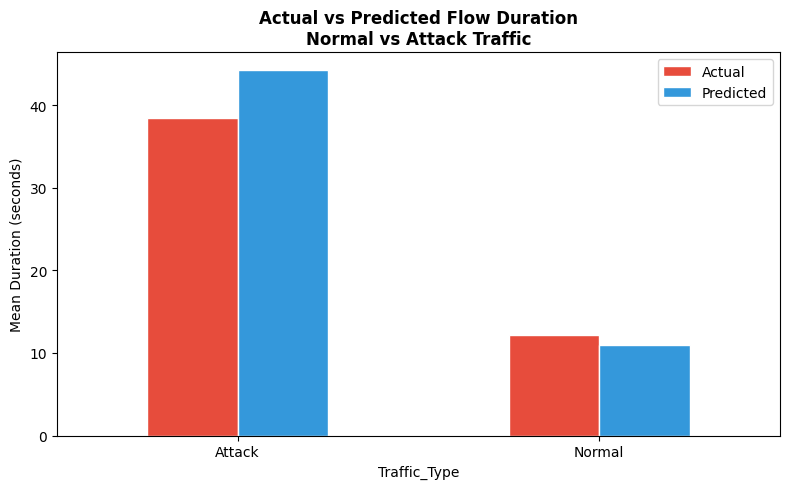

In [9]:

# CHART — did the model predict Normal and Attack durations correctly?
# Red bar = what actually happened
# Blue bar = what the model predicted
# Closer the bars = better the prediction
comparison[['Actual Duration (s)', 'Predicted Duration (s)']].plot(
    kind='bar',
    color=['#e74c3c', '#3498db'],
    edgecolor='white',
    figsize=(8, 5)
)

plt.title('Actual vs Predicted Flow Duration\nNormal vs Attack Traffic',
          fontweight='bold')
plt.ylabel('Mean Duration (seconds)')
plt.xticks(rotation=0)
plt.legend(['Actual', 'Predicted'])
plt.tight_layout()
plt.savefig('03_lr_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()




###Observations
The model overestimates how long attack flows last and underestimates how long normal flows last. It knows something is different about attack traffic — it just can't say what. That's the limit of regression here

In [13]:

# =============================================================
# DECISION TREES — asking the model to make a decision
# Regression told us attack traffic behaves differently
# but couldn't name it. Decision Trees can.
# It builds a series of yes/no questions from the data:
# "Is Init_Win_bytes_forward < 500? Yes → likely an attack"
# =============================================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Features and target
X = df[features]
y = df['Attack Type']

# Train test split
# Split into training and test sets
# stratify=y is important here — it makes sure every attack type
# appears in both train and test sets proportionally
# without it, rare classes like Web Attacks might not appear in test at all
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape}')
print(f'Test set     : {X_test.shape}')
print(f'\nClass distribution in training set:')
print(y_train.value_counts())

Training set : (2016600, 7)
Test set     : (504151, 7)

Class distribution in training set:
Attack Type
Normal Traffic    1676045
DoS                154996
DDoS               102411
Port Scanning       72555
Brute Force          7320
Web Attacks          1714
Bots                 1559
Name: count, dtype: int64


In [14]:

# Build the Decision Tree
# max_depth=5 — limits how deep the tree grows
# a deeper tree memorises the training data but fails on new data (overfitting)
# depth 5 keeps it simple enough to generalise and explain to a non-technical audience

# class_weight='balanced' — tells the model to pay extra attention to rare classes
# without this, the model ignores Web Attacks and Bots (less than 0.2% of data)
# and just predicts Normal Traffic for everything — looks good on paper, useless in a SOC

# random_state=42 — same result every time we run it
dt = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

# Train the model — this is where it builds the yes/no decision rules
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print('Decision Tree trained ✅')

# Compare training vs test accuracy
# if training accuracy is much higher than test — the model is overfitting
# similar scores mean the model generalises well to new data

print(f'\nTraining Accuracy : {dt.score(X_train, y_train):.4f}')
print(f'Test Accuracy     : {dt.score(X_test, y_test):.4f}')

Decision Tree trained ✅

Training Accuracy : 0.6671
Test Accuracy     : 0.6677


###Observations
Training Accuracy : 66.71%
Test Accuracy     : 66.77%

Training and test accuracy are almost identical — the model is not overfitting.
It generalises well to new unseen traffic.


In [15]:
# How well did the model do for each attack type?
# Accuracy alone doesn't tell the full story — this does

# Three numbers per class:
# Precision — when the model said "this is a DDoS", how often was it right?
# Recall    — out of all the real DDoS attacks, how many did the model catch?
# F1        — balance between the two, useful when both matter

# In security, Recall matters most
# Missing a real attack (low Recall) is worse than a false alarm (low Precision)
# A false alarm wastes an analyst's time
# A missed attack could mean a breach
print(classification_report(y_test, y_pred_dt))

                precision    recall  f1-score   support

          Bots       0.36      0.27      0.31       389
   Brute Force       0.08      0.77      0.15      1830
          DDoS       0.22      1.00      0.36     25603
           DoS       0.43      0.88      0.58     38749
Normal Traffic       0.99      0.61      0.76    419012
 Port Scanning       0.73      0.99      0.84     18139
   Web Attacks       0.06      0.90      0.12       429

      accuracy                           0.67    504151
     macro avg       0.41      0.77      0.45    504151
  weighted avg       0.89      0.67      0.72    504151



### Observations:
#
Good news — the model catches most attacks
* DDoS        : 100% caught — missed none
* Port Scan   : 99% caught
*  Web Attacks : 90% caught — great for such a rare class
*  DoS         : 88% caught
#
The problem — too many false alarms
* Web Attacks : only 6% precision — flags 15 innocent flows for every real attack
* Brute Force : only 8% precision — same issue
* DDoS        : 22% precision — catches everything but raises too many false alerts
#
Think of it like a car alarm that never misses a thief but also goes off when a dog walks past. In a SOC, analysts would be flooded with alerts and start ignoring them. That's alert fatigue — a real problem in security operations
#
Why is accuracy only 67%?
Because the model is actually trying to find attacks. A lazy model that just predicts Normal for everything scores 83%. Lower accuracy here means the model is doing its job


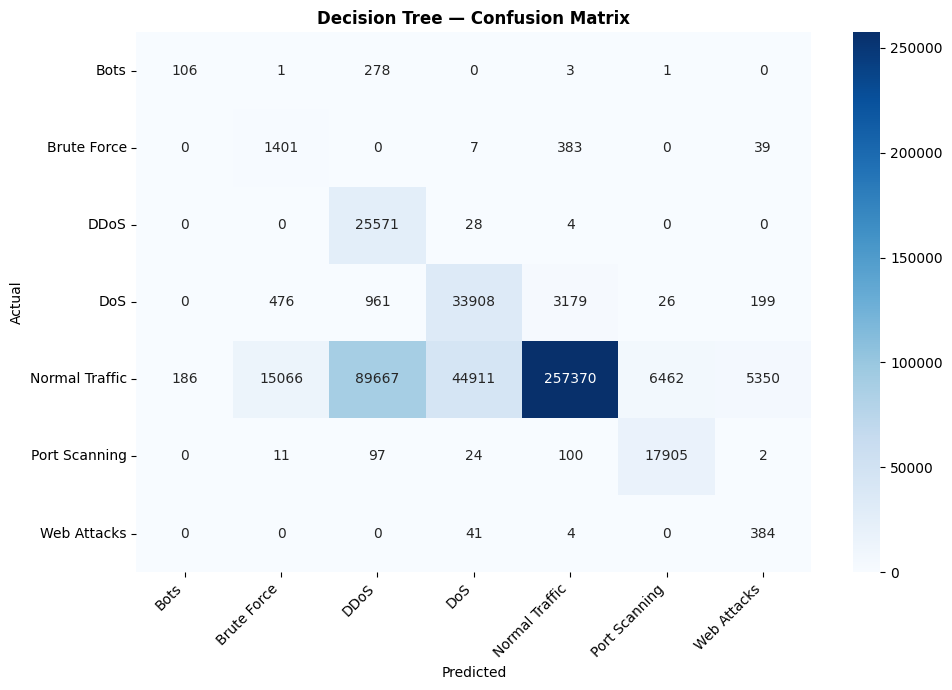

In [16]:
# CONFUSION MATRIX — see exactly where the model gets confused
# Each row = what the traffic actually was
# Each column = what the model predicted
# Numbers on the diagonal = correct predictions (darker = more correct)
# Numbers off the diagonal = mistakes (wrong classifications)
# Example: a number in the DDoS row, Normal column = DDoS traffic mistaken for Normal

import seaborn as sns

cm = confusion_matrix(y_test, y_pred_dt,
                      labels=dt.classes_)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=dt.classes_,
            yticklabels=dt.classes_,
            cmap='Blues')
plt.title('Decision Tree — Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('04_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

###Observations:

* The model's biggest mistakes are attacking normal traffic as attacks
* Normal Traffic mistaken for DDoS        : 89,667 flows wrongly flagged
*  Normal Traffic mistaken for DoS         : 44,911 flows wrongly flagged
*  Normal Traffic mistaken for Brute Force : 15,066 flows wrongly flagged

This explains the low Precision we saw in the classification report. The model is oversensitive — it would rather raise a false alarm than miss a real attack (because we used class_weight='balanced')
#
In a real SOC this means analysts would spend a lot of time investigating normal traffic that the model flagged as suspicious. That's the Precision vs Recall tradeoff in action
#
There's no perfect answer — it depends on the organisation's risk appetite
High security environment = accept the false alarms, catch every attack
Analyst capacity is limited = tune the model to reduce noise

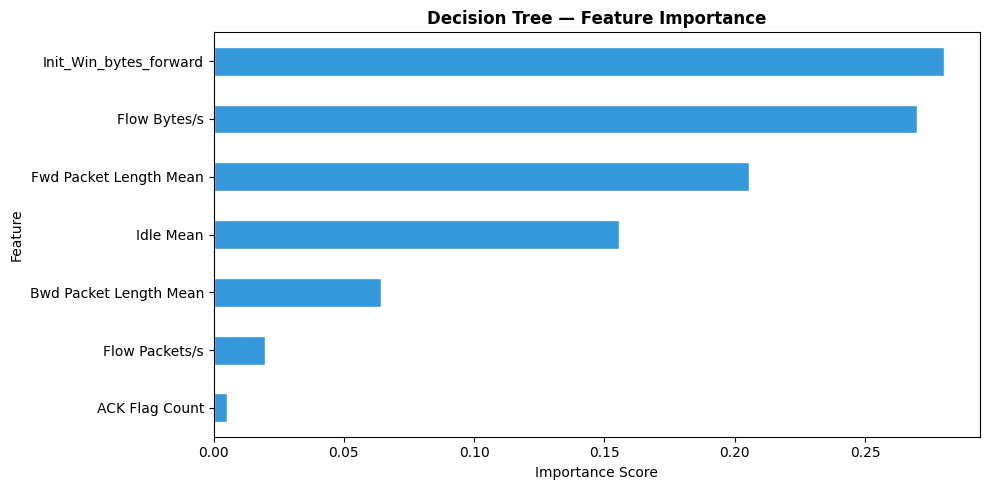

In [17]:
# FEATURE IMPORTANCE — which features did the model actually use to make decisions?
# The Decision Tree gives each feature a score between 0 and 1
# Higher score = that feature was more useful in splitting the data correctly
# All scores add up to 1.0
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=True)

importance_df.plot(
    kind='barh',
    x='Feature',
    y='Importance',
    color='#3498db',
    edgecolor='white',
    figsize=(10, 5),
    legend=False
)

plt.title('Decision Tree — Feature Importance', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


#### Observations:
* Init_Win_bytes_forward (~0.28) — top feature
* Attack tools set abnormal TCP window sizes, real OS don't


In [18]:
# Increasing Model depth
# what happens if we let the tree grow deeper?
# max_depth=5 was our first attempt — kept it simple
# max_depth=10 lets the model learn more complex patterns
# but risks memorising the training data (overfitting)

dt2 = DecisionTreeClassifier(
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

dt2.fit(X_train, y_train)
y_pred_dt2 = dt2.predict(X_test)

print(classification_report(y_test, y_pred_dt2))

                precision    recall  f1-score   support

          Bots       0.03      0.97      0.06       389
   Brute Force       0.68      0.99      0.81      1830
          DDoS       0.83      1.00      0.91     25603
           DoS       0.92      0.99      0.95     38749
Normal Traffic       1.00      0.92      0.96    419012
 Port Scanning       0.74      1.00      0.85     18139
   Web Attacks       0.09      0.98      0.17       429

      accuracy                           0.94    504151
     macro avg       0.61      0.98      0.67    504151
  weighted avg       0.97      0.94      0.95    504151



Observations — max_depth=10 vs max_depth=5

*   Recall improved across all classes — accuracy jumped to 94%
* Bots : 27% → 97% but Precision collapsed to 3%
* More depth = catches more attacks but drowns analysts in noise
* Sticking with max_depth=5 — more realistic for real deployment





In [19]:

####################################################################
# CLUSTERING — K-Means and t-SNE
#
# Everything so far was supervised — we told the model what attacks look like
# Clustering is unsupervised — no labels, no guidance
# We just say "find 7 groups" and see what it discovers on its own
#
# This is closer to how real anomaly detection works in SOC tools
# The model finds unusual behaviour without being told what to look for
####################################################################

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# Scale features — critical for K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

print(f'Scaled data shape: {X_scaled.shape}')
print('\nFeatures being clustered:')
for f in features:
    print(f'  • {f}')

Scaled data shape: (2520751, 7)

Features being clustered:
  • Flow Packets/s
  • Flow Bytes/s
  • Fwd Packet Length Mean
  • Bwd Packet Length Mean
  • ACK Flag Count
  • Init_Win_bytes_forward
  • Idle Mean


###Observations
2,520,751 network flows scaled and ready for clustering.

7 features selected based on EDA and Decision Tree findings:
- Flow Packets/s — packet rate varies significantly across attack types
- Flow Bytes/s — throughput differs between normal and attack traffic
- Fwd Packet Length Mean — packet sizes reveal scanning and exfil behaviour
- Bwd Packet Length Mean — response size indicates server behaviour
- ACK Flag Count — TCP handshake completeness
- Init_Win_bytes_forward — top feature from Decision Tree, attack tools set abnormal values
- Idle Mean — slow attacks stay quiet between bursts

Same features used throughout the notebook for consistency.
Allows direct comparison between supervised and unsupervised results.

In [20]:

####################################################################
# TRAIN K-MEANS
# We tell it to find 7 groups — same as the number of traffic types
# n_init=10 means it runs 10 times with different starting points
# and picks the best result — reduces chance of a bad clustering
####################################################################
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
kmeans.fit(X_scaled)

df['Cluster'] = kmeans.labels_

print('K-Means clustering complete ✅')
print(f'\nCluster sizes:')
print(df['Cluster'].value_counts().sort_index())

K-Means clustering complete ✅

Cluster sizes:
Cluster
0    1292199
1       2073
2     105629
3     201080
4      28472
5     378350
6     512948
Name: count, dtype: int64


### Observations: K-Means — Cluster Sizes

Cluster 0 : 1,292,199 — largest cluster, likely dominated by normal traffic
Cluster 1 :     2,073 — tiny isolated cluster, very distinct traffic pattern
Cluster 2 :   105,629
Cluster 3 :   201,080
Cluster 4 :    28,472
Cluster 5 :   378,350
Cluster 6 :   512,948


In [ ]:
# Cross tabulate clusters vs actual labels
cross_tab = pd.crosstab(df['Cluster'], df['Attack Type'])
print('Cluster vs Actual Attack Type:')
print(cross_tab)

Cluster vs Actual Attack Type:
Attack Type  Bots  Brute Force   DDoS     DoS  Normal Traffic  Port Scanning  \
Cluster                                                                        
0            1181            0  43161    8122         1195308          44427   
1               0            0      0       4            2069              0   
2              58           12      9     254          104160           1135   
3               0            0  37575  143808           19672             25   
4              45            0      0      39           28388              0   
5               2         6953     50   28750          295544          45046   
6             662         2185  47219   12768          449916             61   

Attack Type  Web Attacks  
Cluster                   
0                      0  
1                      0  
2                      1  
3                      0  
4                      0  
5                   2005  
6                    137  


Cluster 3 : 143,808 DoS + 37,575 DDoS — found without any labels. Standout result.

Cluster 1 : 2,069 Normal — tiny isolated cluster, very distinct traffic pattern

Cluster 0 : Normal dominant but mixed with Port Scanning and DDoS

Cluster 5 : 6,953 Brute Force + 2,005 Web Attacks hiding in normal traffic

K-Means found DoS/DDoS naturally — but rare attacks scattered across normal clusters.
Same blind spot as supervised learning. Rare attacks are hard to find no matter the technique.

In [21]:
####################################################################
# t-SNE — making the invisible visible
#
# Our data has 7 features — impossible to visualise directly
# t-SNE squashes 7 dimensions down to 2 so we can plot it
# Points that are similar in 7D will appear close together in 2D
# Points that are different will appear far apart
#
# If we see clear separation in the plot — the data has real structure
# and ML has something meaningful to learn from
####################################################################
np.random.seed(42)
sample_idx = np.random.choice(len(df), 5000, replace=False)

X_sample = X_scaled[sample_idx]
labels_sample = df['Attack Type'].iloc[sample_idx]
cluster_sample = df['Cluster'].iloc[sample_idx]

# Run t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

print('t-SNE complete ✅')

t-SNE complete ✅


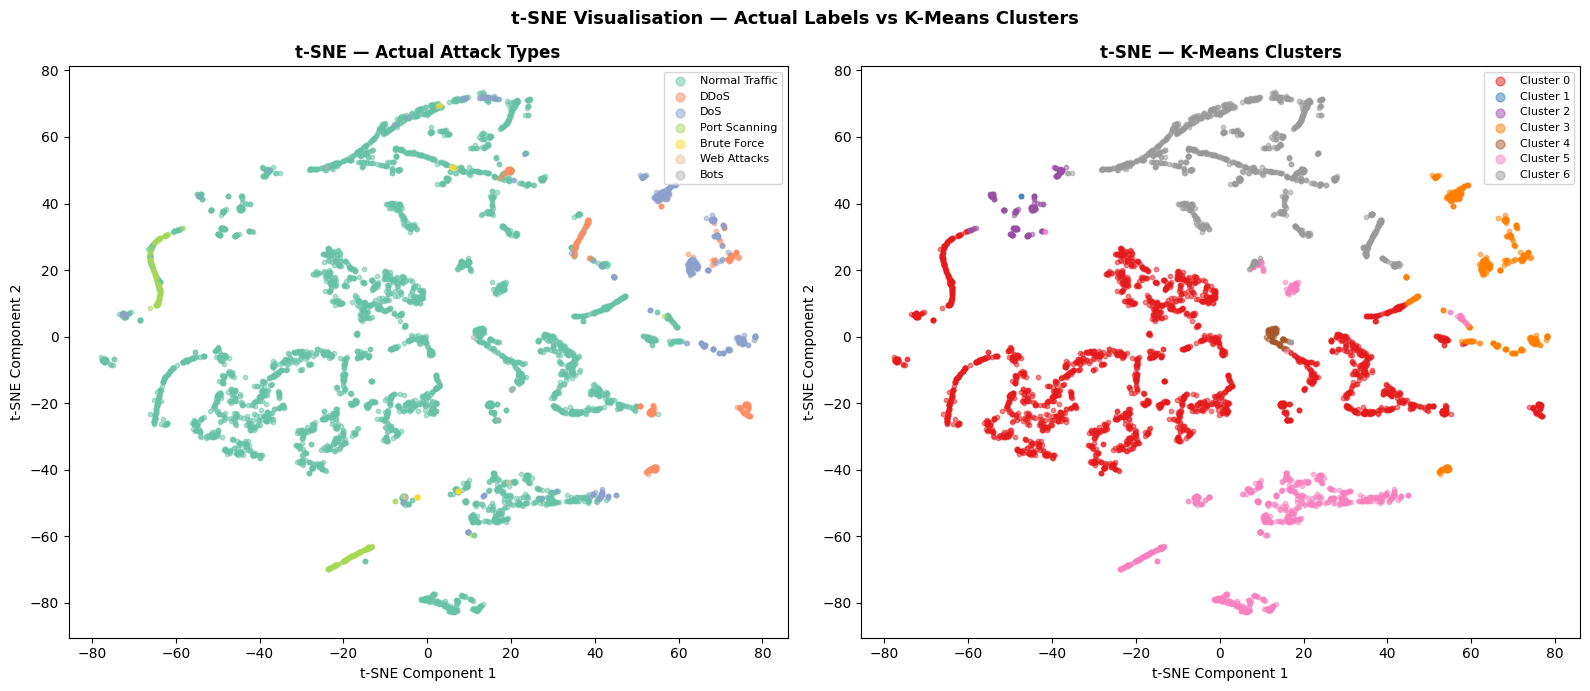

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
####################################################################
# t-SNE VISUALISATION — two plots side by side
# Left  : each dot coloured by actual attack type
# Right : each dot coloured by K-Means cluster number
#
# Comparing the two tells us how well K-Means matched reality
# If the colours line up — clustering worked well
# If they don't — K-Means grouped things differently than the true labels
####################################################################

# --- Left: Actual labels ---
attack_types = labels_sample.unique()
colors = plt.cm.Set2(np.linspace(0, 1, len(attack_types)))
color_map = dict(zip(attack_types, colors))

for label in attack_types:
    mask = labels_sample == label
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=[color_map[label]], label=label,
                   alpha=0.5, s=10)

axes[0].set_title('t-SNE — Actual Attack Types', fontweight='bold')
axes[0].legend(markerscale=2, fontsize=8)
axes[0].set_xlabel('t-SNE Component 1')
axes[0].set_ylabel('t-SNE Component 2')

# --- Right: K-Means clusters ---
cluster_colors = plt.cm.Set1(np.linspace(0, 1, 7))
for cluster in range(7):
    mask = cluster_sample == cluster
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=[cluster_colors[cluster]], label=f'Cluster {cluster}',
                   alpha=0.5, s=10)

axes[1].set_title('t-SNE — K-Means Clusters', fontweight='bold')
axes[1].legend(markerscale=2, fontsize=8)
axes[1].set_xlabel('t-SNE Component 1')
axes[1].set_ylabel('t-SNE Component 2')

plt.suptitle('t-SNE Visualisation — Actual Labels vs K-Means Clusters',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('06_tsne.png', dpi=150, bbox_inches='tight')
plt.show()


###Observations:
Clusters are visually separated.The data has real structure — different traffic types occupy different regions. ML is not guessing, it has something to learn from.


k=2 done
k=3 done
k=4 done
k=5 done
k=6 done
k=7 done
k=8 done
k=9 done
k=10 done
k=11 done


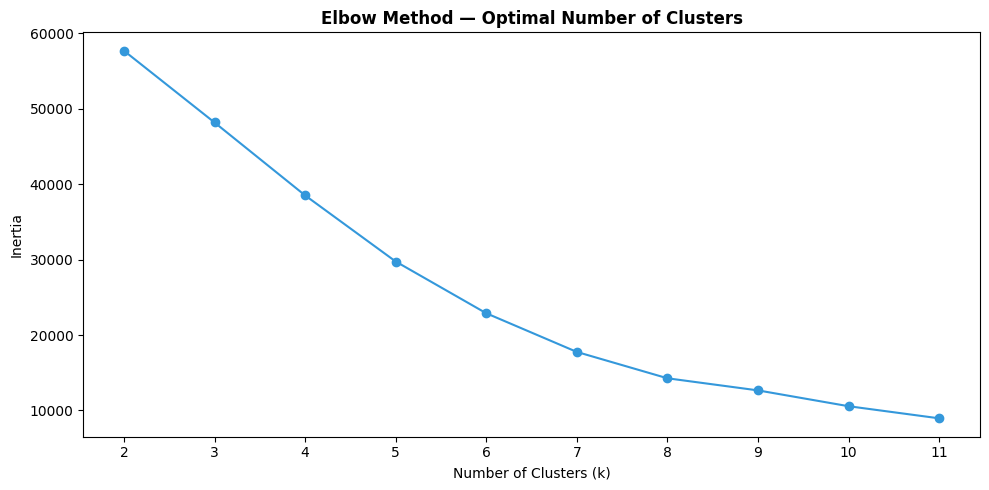

In [23]:
####################################################################
# ELBOW METHOD
# Run K-Means with different cluster numbers and plot inertia
# Inertia = how tight the clusters are (lower = better)
# The "elbow" in the curve = optimal number of clusters
####################################################################

from sklearn.cluster import KMeans

# Sample for speed — elbow method on 2.5M rows would take too long
np.random.seed(42)
elbow_idx = np.random.choice(len(df), 10000, replace=False)
X_elbow = X_scaled[elbow_idx]

inertia = []
k_range = range(2, 12)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_elbow)
    inertia.append(km.inertia_)
    print(f'k={k} done')

# Plot
pd.Series(inertia, index=k_range).plot(
    kind='line',
    marker='o',
    color='#3498db',
    figsize=(10, 5)
)
plt.title('Elbow Method — Optimal Number of Clusters', fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.tight_layout()
plt.savefig('07_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

### Elbow Method — Results

Elbow appears around k=6 to k=7.
This validates our choice of 7 clusters — one per traffic type.

The curve is gradual with no sharp elbow.
This tells us traffic types don't have perfectly clean boundaries —
they blend into each other, especially normal traffic and attack traffic.
This explains why the model struggles with rare attacks like Web Attacks and Bots.

Adding more clusters beyond 7 gives diminishing returns.

In [24]:
####################################################################
# SILHOUETTE SCORE
# Measures how well each point fits its own cluster
# Score ranges from -1 to 1:
#   1.0  = perfectly placed in the right cluster
#   0.0  = sitting on the boundary between two clusters
#  -1.0  = probably in the wrong cluster
#
# We use a sample — computing this on 2.5M rows is very slow
####################################################################

from sklearn.metrics import silhouette_score

# Sample for speed
np.random.seed(42)
sil_idx = np.random.choice(len(df), 10000, replace=False)
X_sil = X_scaled[sil_idx]
sil_labels = df['Cluster'].iloc[sil_idx]

score = silhouette_score(X_sil, sil_labels)
print(f'Silhouette Score: {score:.4f}')

####################################################################
# HOW TO READ THE RESULT:
# Above 0.5  = clusters are reasonably well separated
# 0.2 - 0.5  = some overlap between clusters
# Below 0.2  = clusters are heavily mixed
#
# Given what we saw in the elb

Silhouette Score: 0.6087


### Observations: Silhouette Score

Silhouette Score: 0.61

Above 0.5 = clusters are reasonably well separated. 0.61 is a solid result.
Confirms the t-SNE finding traffic types occupy distinct regions.

Not close to 1.0 some overlap exists between clusters.
Normal traffic bleeds into attack clusters ,explains the rare attack blind spot.
The clustering is working. The data is just messy. That's reality.

In [25]:
####################################################################
# CLUSTER PURITY
# For each cluster — what percentage is the dominant class?
# 100% pure = all flows in that cluster are the same traffic type
# Low purity = the cluster is a mix of different traffic types
####################################################################

# For each cluster find the dominant class and calculate purity
cluster_labels = df[['Cluster', 'Attack Type']].copy()

purity_results = []

for cluster in sorted(df['Cluster'].unique()):
    cluster_data = cluster_labels[cluster_labels['Cluster'] == cluster]
    total = len(cluster_data)
    dominant_class = cluster_data['Attack Type'].value_counts().index[0]
    dominant_count = cluster_data['Attack Type'].value_counts().iloc[0]
    purity = dominant_count / total * 100

    purity_results.append({
        'Cluster': cluster,
        'Size': total,
        'Dominant Class': dominant_class,
        'Purity %': round(purity, 2)
    })

purity_df = pd.DataFrame(purity_results)
print('Cluster Purity Results:')
print(purity_df.to_string(index=False))

# Overall purity score
overall_purity = sum(
    df['Attack Type'].iloc[df[df['Cluster'] == c].index].value_counts().iloc[0]
    for c in df['Cluster'].unique()
) / len(df) * 100
print(f'\\nOverall Purity: {overall_purity:.2f}%')

Cluster Purity Results:
 Cluster    Size Dominant Class  Purity %
       0 1292199 Normal Traffic     92.50
       1    2073 Normal Traffic     99.81
       2  105629 Normal Traffic     98.61
       3  201080            DoS     71.52
       4   28472 Normal Traffic     99.70
       5  378350 Normal Traffic     78.11
       6  512948 Normal Traffic     87.71
\nOverall Purity: 88.04%


### Observations:
* Cluster 3 is the standout - 71% DoS found with zero supervision.
* Cluster 5 is the problem - stealthy attacks hiding in normal traffic.
* Overall 88% purity confirms K-Means found meaningful structure in the data.

In [27]:
####################################################################
# ANOMALY DETECTION
# Flows that don't fit well into any cluster are the most suspicious
# K-Means assigns every point to a cluster — but some points
# are far from their cluster centre (high distance = anomaly)
# In security these outliers could be novel attacks or unusual behaviour
####################################################################

# Calculate distance of each point from its cluster centre
# The further a point is from its centre the more anomalous it is
centres = kmeans.cluster_centers_
distances = np.min(
    np.linalg.norm(X_scaled[:, np.newaxis] - centres, axis=2), axis=1
)

# Add distances to dataframe
df['Anomaly_Score'] = distances

# Top 1% most anomalous flows
threshold = np.percentile(distances, 99)
anomalies = df[df['Anomaly_Score'] > threshold]

print(f'Anomaly threshold (99th percentile) : {threshold:.4f}')
print(f'Total anomalies flagged              : {len(anomalies):,}')
print(f'\\nAnomaly breakdown by traffic type:')
print(anomalies['Attack Type'].value_counts())

Anomaly threshold (99th percentile) : 3.9120
Total anomalies flagged              : 25,208
\nAnomaly breakdown by traffic type:
Attack Type
Normal Traffic    22886
DoS                1558
Port Scanning       410
DDoS                302
Bots                 47
Brute Force           5
Name: count, dtype: int64


In [29]:
####################################################################
# DBSCAN — Density Based Spatial Clustering
# Unlike K-Means, DBSCAN:
# 1. Does not need you to specify number of clusters upfront
# 2. Finds clusters of any shape, not just round ones
# 3. Automatically labels outliers as -1 (noise points)
#
# In security, those noise points = potential anomalies
# Anything DBSCAN can't fit into a cluster is flagged automatically
####################################################################

from sklearn.cluster import DBSCAN

# Sample for speed — DBSCAN on 2.5M rows would take hours
np.random.seed(42)
db_idx = np.random.choice(len(df), 10000, replace=False)
X_db = X_scaled[db_idx]
labels_db = df['Attack Type'].iloc[db_idx]

# eps = maximum distance between two points to be considered neighbours
# min_samples = minimum points needed to form a cluster
# these values may need tuning — start here and adjust based on results
dbscan = DBSCAN(eps=0.5, min_samples=10)
db_labels = dbscan.fit_predict(X_db)

# How many clusters did DBSCAN find?
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

print(f'Clusters found : {n_clusters}')
print(f'Noise points   : {n_noise} ({n_noise/len(db_labels)*100:.1f}%)')

# What attack types are in the noise points?
print(f'\\nNoise point breakdown by traffic type:')
print(labels_db[db_labels == -1].value_counts())

Clusters found : 19
Noise points   : 376 (3.8%)
\nNoise point breakdown by traffic type:
Attack Type
Normal Traffic    315
DoS                49
DDoS                6
Port Scanning       5
Bots                1
Name: count, dtype: int64
